# CNN exploration (original notebook)

This is the exploratory notebook the CNN backend came from, kept as the experimental
record: dataset download, augmentation, the convolutional architecture, the training
loop, the confusion matrix, feature maps and Grad-CAM.

**It is not the pipeline.** The production path lives in `src/asl/` and is run with
`asl train --config configs/cnn.yaml`. Two things in here are fixed there and worth
flagging:

1. the label map is hard-coded and maps index 28 to `del` twice, so `nothing` is
   displayed as `del` - the package derives class names from the data instead;
2. the train/test split is random over near-duplicate frames, which inflates the
   98.74% reported below - see `docs/evaluation.md`.


In [1]:
import os
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader,Dataset
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch.nn as nn
import torchvision

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


Downloading the dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [ ]:
# import shutil
# import os
# #moving the downloaded datasets to the current folder
# DEST = "/content/asl-alphabet"

# # Remove old copy if exists
# if os.path.exists(DEST):
#     shutil.rmtree(DEST)

# shutil.copytree(path, DEST)

# print("Dataset moved to:", DEST)

In [4]:
# the transforms for the train data first resize for the input of the CNN, then random brightness and contrast
#random cropping and resizing
train_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomResizedCrop(100, scale=(0.9, 1.0)),
    transforms.ToTensor()
])
# we use the transofrms for the test data
test_transform =transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])
# getting the data set from the folders
dataset=ImageFolder(root=path+'/asl_alphabet_train/asl_alphabet_train')


In [5]:
print(len(dataset))
img,label=dataset[6]
print( np.array(img).shape)
print(label)

87000
(200, 200, 3)
0


Visualizing some samples of the data sets

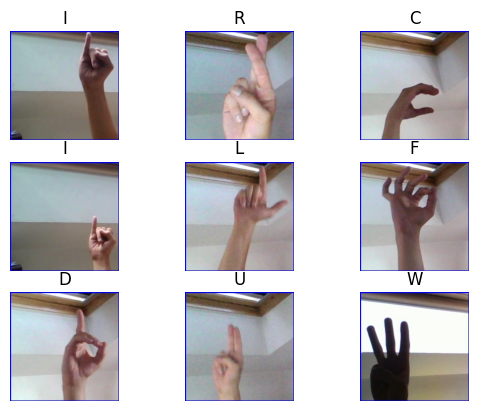

In [6]:
import string
letter_map = {i:letter for i,letter in enumerate(string.ascii_uppercase)}
letter_map|= {26:'del',27:"nothing",28:"del"}
rows,cols=3,3
fig,axs=plt.subplots(rows,cols)
for i in range(rows):
  for j in range(cols):
    img,label=dataset[np.random.randint(len(dataset))]
    axs[i,j].imshow(np.array(img))
    axs[i,j].set_title(letter_map[label])
    axs[i,j].axis('off')


test-train spliting the dataset  

In [7]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

train_indices, test_indices = train_test_split(
    list(range(len(dataset))), # spliting the indicies
    test_size=0.2,
    stratify=dataset.targets,   # keeps class balance
    random_state=42
)

print(train_indices)
print(test_indices)

[691, 73277, 75831, 75679, 23974, 80579, 83508, 61209, 12104, 70711, 24043, 66091, 62083, 70109, 40642, 4547, 14580, 54062, 23495, 44729, 15649, 14829, 34130, 65586, 73259, 48909, 81137, 47917, 6744, 3926, 11382, 50765, 25524, 27124, 71924, 39689, 1555, 26408, 84532, 16616, 83737, 48503, 65172, 63297, 18873, 47833, 22656, 64365, 67234, 28358, 45604, 30745, 60758, 35110, 8745, 27743, 32227, 72491, 35940, 15096, 26255, 84630, 9428, 27010, 31898, 34866, 79645, 52407, 11672, 56701, 11128, 6844, 64121, 17528, 76620, 71607, 4349, 8857, 40888, 21966, 70451, 12254, 19250, 696, 51990, 4065, 86436, 53120, 59556, 36047, 17575, 67275, 29961, 26869, 86504, 74668, 80460, 42315, 83603, 737, 9189, 62032, 6430, 82848, 56495, 48726, 17250, 50455, 58691, 51761, 3836, 26773, 75406, 12436, 1874, 76867, 24606, 81779, 73541, 16459, 85948, 22366, 11050, 27666, 85277, 36424, 79986, 14279, 83968, 77301, 78835, 43473, 50930, 13522, 60521, 70416, 57194, 42747, 35600, 64597, 78838, 11068, 5945, 20993, 82079, 11594

In [8]:
train_dataset = ImageFolder(
    root=path+'/asl_alphabet_train/asl_alphabet_train',
    transform=train_transform
)

test_dataset = ImageFolder(
    root=path+'/asl_alphabet_train/asl_alphabet_train',
    transform=test_transform
)


In [10]:
from torch.utils.data import Subset
train_dataset = Subset(train_dataset, train_indices)
test_dataset = Subset(test_dataset, test_indices)

print(len(train_dataset))
print(len(test_dataset))

69600
17400


visualizing the train data_set and test data set

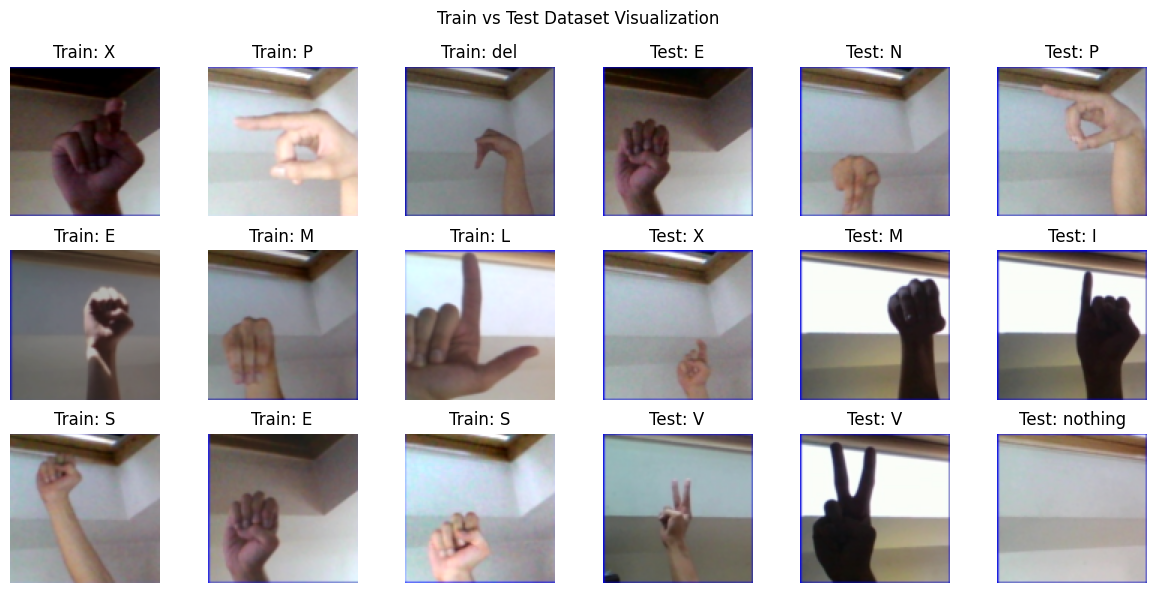

In [11]:
import string
letter_map = {i:letter for i,letter in enumerate(string.ascii_uppercase)}
letter_map|= {26:'del',27:"nothing",28:"del"}
rows,cols=3,3
fig, axs = plt.subplots(rows, cols * 2, figsize=(12, 6))
fig.suptitle("Train vs Test Dataset Visualization")

for i in range(rows):
    for j in range(cols):

        # ---- TRAIN ----
        img, label = train_dataset[np.random.randint(len(train_dataset))]
        axs[i, j].imshow(img.permute(1, 2, 0).numpy())
        axs[i, j].set_title(f"Train: {letter_map[label]}")
        axs[i, j].axis('off')

        # ---- TEST ----
        img, label = test_dataset[np.random.randint(len(test_dataset))]
        axs[i, j + cols].imshow(img.permute(1, 2, 0).numpy())
        axs[i, j + cols].set_title(f"Test: {letter_map[label]}")
        axs[i, j + cols].axis('off')

plt.tight_layout()
plt.show()

In [12]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64)


CNN classifier

In [13]:
from torch.nn.modules.pooling import MaxPool2d
class Classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv= nn.Sequential(
        nn.Conv2d(3,32,5), # (3,100,100) -> (32,96,96)
        nn.ReLU(),
        nn.MaxPool2d(2,2), # (32,96,96) -> (32,48,48)
        nn.BatchNorm2d(32),
        nn.Conv2d(32,64,3), #(32,48,48) -> (64,46,46)
        nn.ReLU(),
        nn.MaxPool2d(2,2), #(64,46,46) -> (64,23,23)
        nn.BatchNorm2d(64),
        nn.Conv2d(64,96,5), # (64,23,23) -> (96,19,19)
        nn.ReLU(),
        nn.MaxPool2d(2,2), #(96,19,19) -> (96,9,9)
        nn.BatchNorm2d(96),
    )
    self.linear = nn.Sequential(
        nn.Linear(96*9*9,128),
        nn.ReLU(),
        nn.LayerNorm(128),
        nn.Linear(128,29)
    )
  def forward(self,input):
    x= self.conv(input)
    x=x.view(x.shape[0],-1)
    x= self.linear(x)
    return x

In [14]:
model = Classifier()

model(next(iter(test_loader))[0])

tensor([[ 0.8902, -0.1189, -0.5042,  ..., -0.7085, -0.0867, -0.0557],
        [ 0.0745,  0.1914,  0.2503,  ..., -0.0820,  0.2058,  0.7383],
        [ 0.1350,  0.3346,  0.1483,  ...,  0.2740, -0.4602, -0.6161],
        ...,
        [ 0.4645, -0.7041,  0.2074,  ..., -0.6229,  0.5306,  0.4760],
        [ 0.0111,  0.5195,  0.2599,  ...,  1.3802,  0.4439, -0.4701],
        [ 0.6481, -0.1868,  0.2505,  ..., -0.1533, -0.3217, -0.2377]],
       grad_fn=<AddmmBackward0>)

Main training block

In [15]:
model=Classifier().to(device)
optimizer=torch.optim.Adam(model.parameters())
loss_function=nn.CrossEntropyLoss()
def train():
  model.train()
  for batch ,(image,label) in enumerate(train_loader):
    image,label=image.to(device),label.to(device)
    output = model(image)
    loss=loss_function(output,label)
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch%30 ==0 :
      print ("current losss ",loss.item())

epochs=4

for i in range(epochs):
  print(f"-------epoch {i+1}-----")
  train()

torch.save(model.state_dict(), "Cnn_model1_SL_4Epoch.pth")

-------epoch 1-----
current losss  3.6041626930236816
current losss  2.6370062828063965
current losss  2.286897659301758
current losss  1.9882094860076904
current losss  1.53181791305542
current losss  1.1952728033065796
current losss  1.1096731424331665
current losss  0.9443197250366211
current losss  0.5297574996948242
current losss  0.730205774307251
current losss  0.5085054636001587
current losss  0.5364105701446533
current losss  0.4208637475967407
current losss  0.24285823106765747
current losss  0.36628270149230957
current losss  0.26352041959762573
current losss  0.2513866424560547
current losss  0.25442931056022644
current losss  0.13986580073833466
current losss  0.19877749681472778
current losss  0.05767784267663956
current losss  0.15756288170814514
current losss  0.22519175708293915
current losss  0.0981701985001564
current losss  0.07038687914609909
current losss  0.26756489276885986
current losss  0.1011253371834755
current losss  0.3369290828704834
current losss  0.1558

In [16]:
#model.load_state_dict(torch.load("Cnn_model1_SL_4Epoch.pth"))

total_score = 0
model.eval()

all_preds = [] #all prediction
all_labels = [] #all true lables
with torch.no_grad():
  for image,label in test_loader:

    image,label=image.to(device),label.to(device)
    outputs=model(image)
    predict=outputs.argmax(1)
    all_preds.extend(predict.cpu().numpy())
    all_labels.extend(label.cpu().numpy())
    score = (predict == label).sum()
    total_score+=score
accuracy = (total_score / len(test_dataset))*100
print(f"accuracy : {accuracy:.2f} %")


accuracy : 98.74 %


In [17]:
model=Classifier()
model.load_state_dict(torch.load("Cnn_model1_SL_4Epoch.pth"))
model.to(device)

Classifier(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Conv2d(64, 96, kernel_size=(5, 5), stride=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (linear): Sequential(
    (0): Linear(in_features=7776, out_features=128, bias=True)
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=128, out_features=29, b

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)


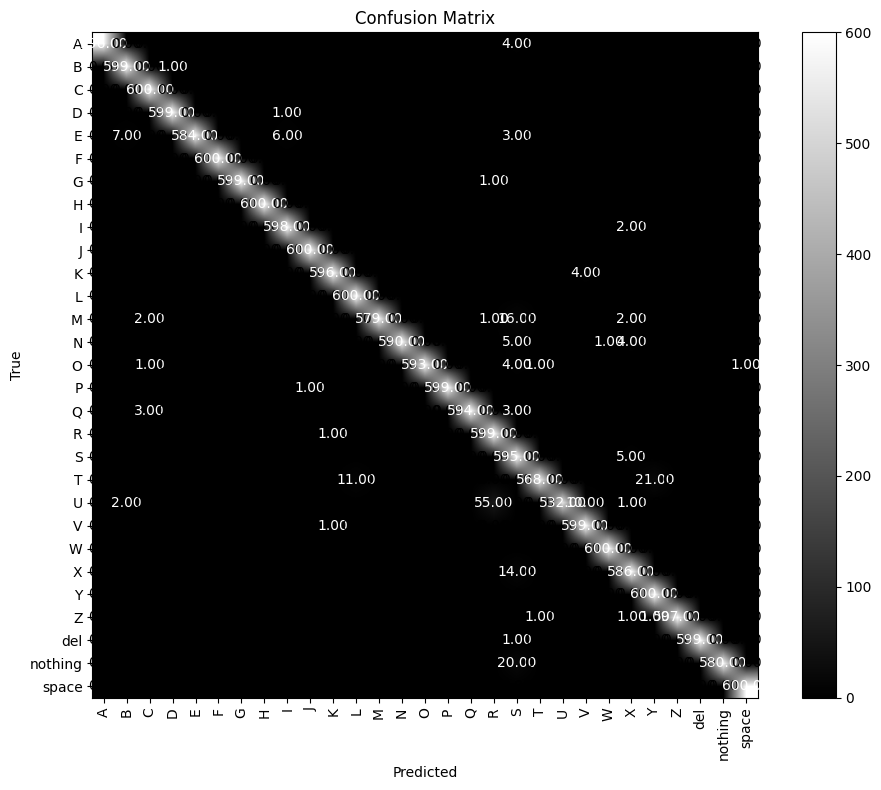

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(
    cm,
    cmap='gray',           # grayscale
    interpolation='bilinear'  # smooth effect
)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# Class names
classes = dataset.classes   # important if using Subset
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()


Visualize Feature Maps (Activations)

In [21]:
model.eval()

img, label = test_dataset[4]
img = img.unsqueeze(0).to(device)  # add batch dimension


In [22]:
activations=[]
with torch.no_grad():
    activation1 = model.conv[0](img)  # first conv layer output
    activations.append(activation1)
    out = model.conv[3]( model.conv[2]( model.conv[1](activation1) ) )
    activation2 = model.conv[4](out)
    activations.append(activation2)
    out = model.conv[7]( model.conv[6]( model.conv[5](activation2) ) )
    activation3 = model.conv[8](out)
    activations.append(activation3)

        # nn.Conv2d(3,32,5), # (3,100,100) -> (32,96,96) 0
        # nn.ReLU(),  1
        # nn.MaxPool2d(2,2), # (32,96,96) -> (32,48,48) 2
        # nn.BatchNorm2d(32), 3
        # nn.Conv2d(32,64,3), #(32,48,48) -> (64,46,46) 4
        # nn.ReLU(),                                  5
        # nn.MaxPool2d(2,2), #(64,46,46) -> (64,23,23)   6
        # nn.BatchNorm2d(64),                           7
        # nn.Conv2d(64,96,5), # (64,23,23) -> (96,19,19) 8
        # nn.ReLU(),
        # nn.MaxPool2d(2,2), #(96,19,19) -> (96,9,9)
        # nn.BatchNorm2d(96),

#Visualization of the first CNN layer filters

In [23]:

def filter_vis(activation,title):
  num_filters = activation.shape[0]

  fig, axs = plt.subplots(4, 8, figsize=(12,6))
  fig.suptitle(f"Feature Maps - {title}")

  for i, ax in enumerate(axs.flat):
      if i < num_filters:
          ax.imshow(activation[i], cmap='gray')
          ax.axis('off')

  plt.tight_layout()
  plt.show()


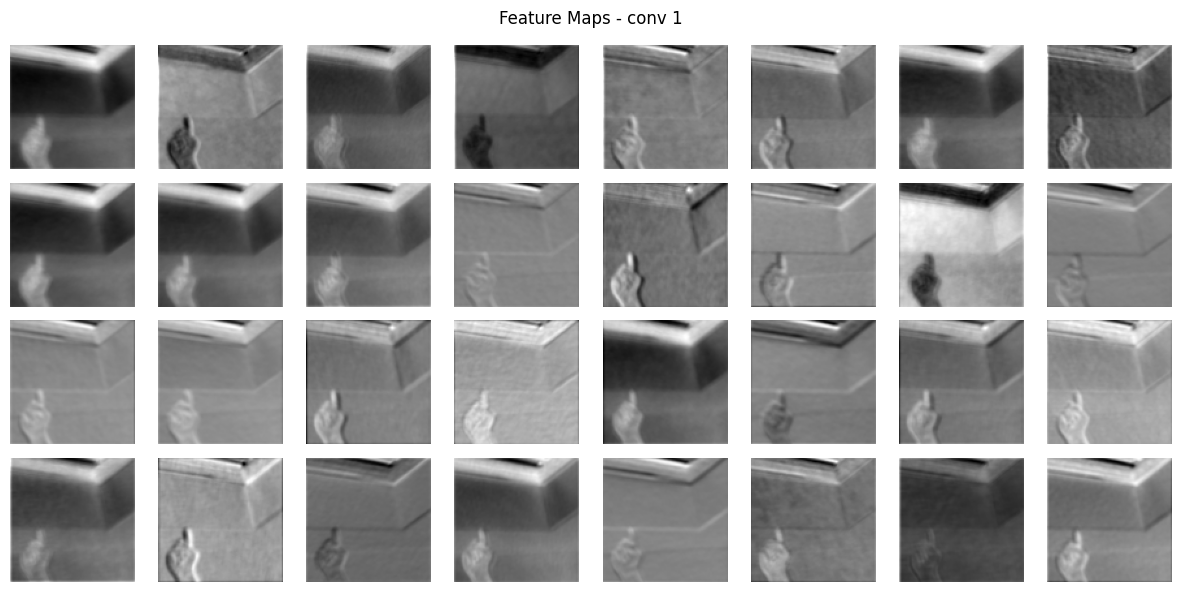

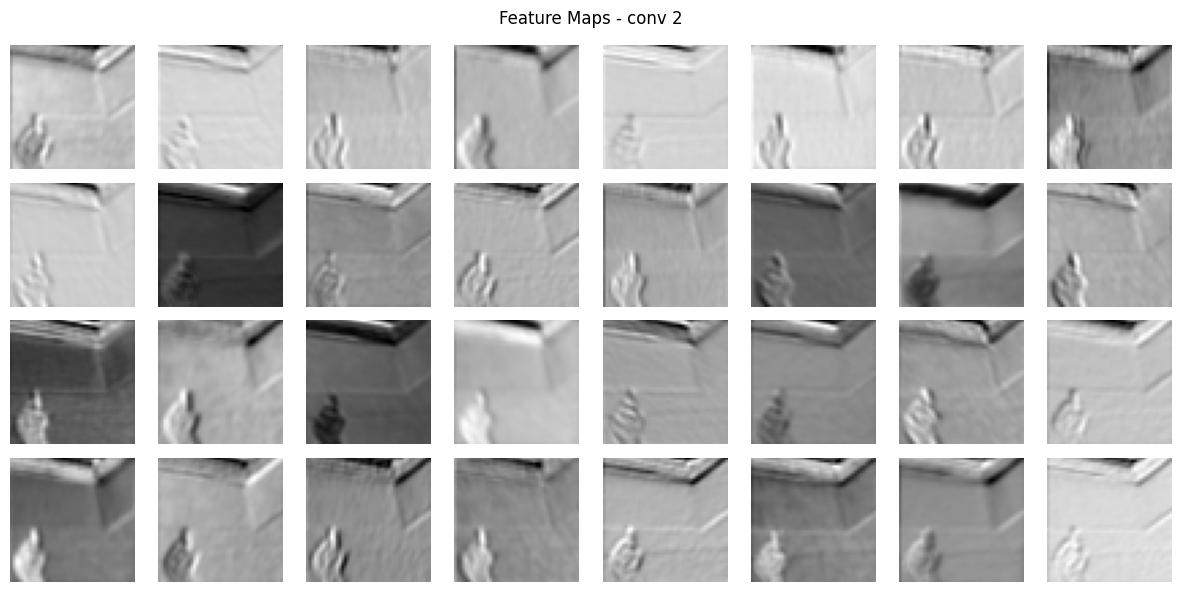

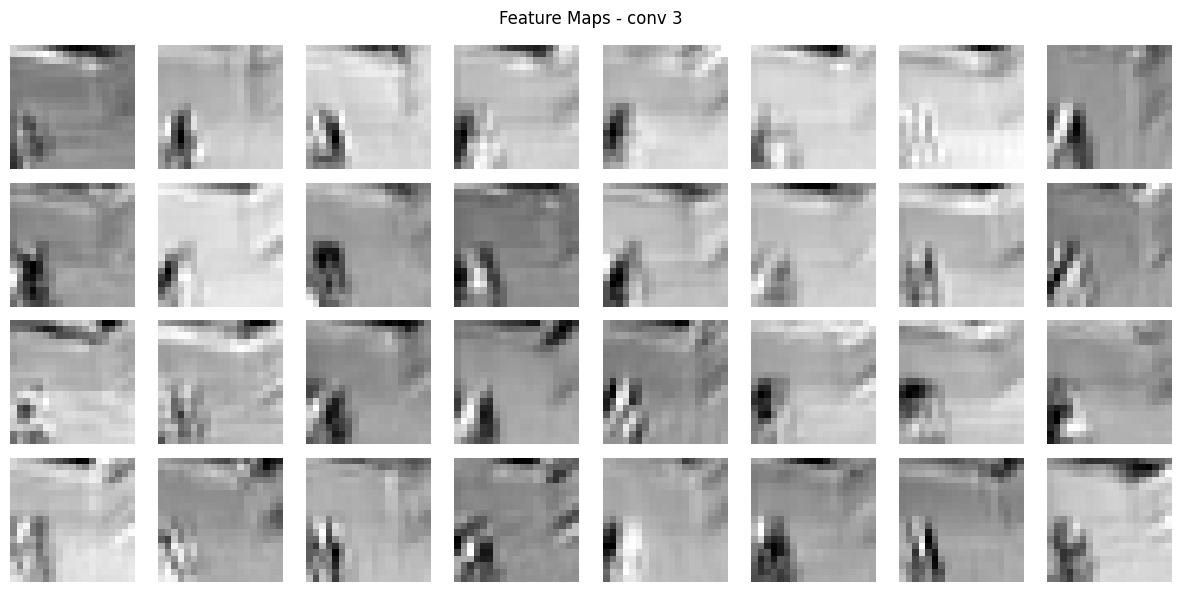

In [24]:
texts =["conv 1" , "conv 2" , "conv 3"]
for i,activation in enumerate(activations) :
  activation = activation.squeeze(0).cpu()
  filter_vis(activation,texts[i])

#Grad-CAM

Verify model is focusing on fingers


In [25]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.cpu().detach().numpy()


In [26]:
def grad_came_sample_imgs(dataset,model,batch):

  out=[]

  for b in range(batch):
    model.eval()
    target_layer = model.conv[-1]
    # Get one test image
    img, label = dataset[np.random.randint(len(dataset))]
    input_tensor = img.unsqueeze(0).to(device)

    # Initialize GradCAM
    grad_cam = GradCAM(model, target_layer)

    # Generate heatmap
    cam = grad_cam.generate(input_tensor)
    out.append((img,label,cam))
  return out

In [27]:
def get_overlay(img,cam):
  # Convert image to numpy
  img_np = img.permute(1, 2, 0).cpu().numpy()

  # Resize heatmap to image size
  cam = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

  # Convert to color heatmap (RED style)
  heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
  heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
  heatmap = heatmap / 255.0

  # Overlay
  overlay = 0.6 * img_np + 0.4 * heatmap
  overlay = np.clip(overlay, 0, 1)

  return overlay


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


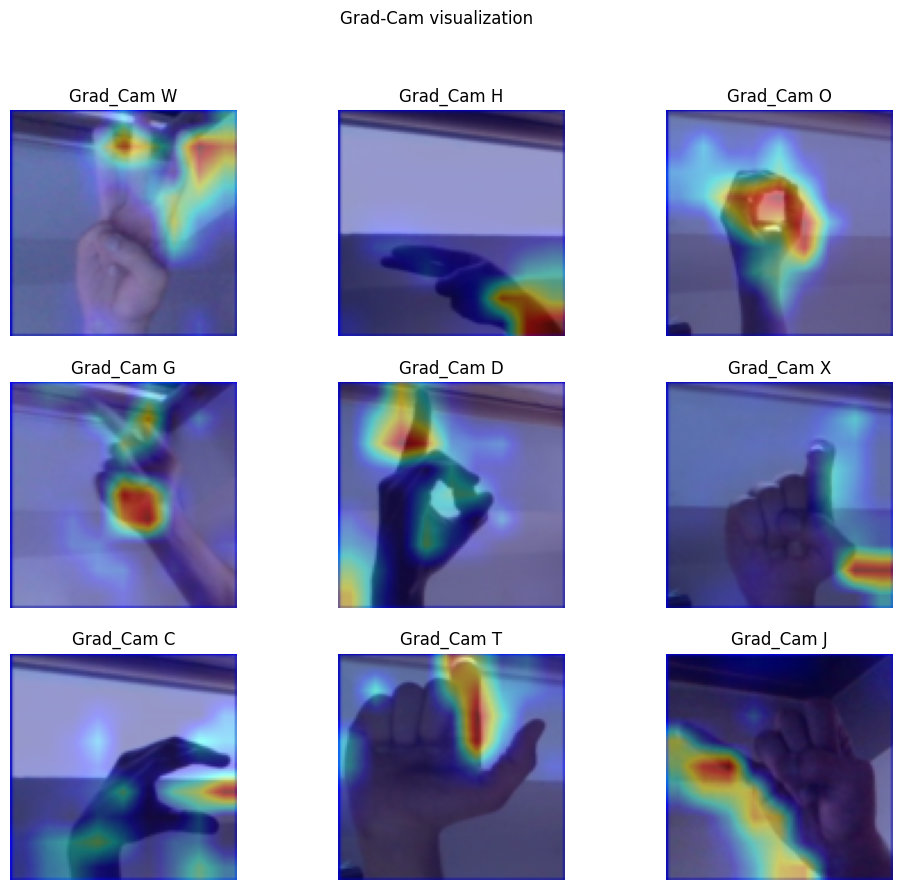

In [28]:
import string
letter_map = {i:letter for i,letter in enumerate(string.ascii_uppercase)}
letter_map|= {26:'del',27:"nothing",28:"del"}
rows,cols=3,3
cam_samples=grad_came_sample_imgs(test_dataset,model,rows*cols)
fig,axs=plt.subplots(rows,cols,figsize=(12, 10))
fig.suptitle("Grad-Cam visualization")
for i in range(rows):
  for j in range(cols):
    img,label,cam=cam_samples[i*rows + j]
    overlay=get_overlay(img,cam)
    axs[i,j].imshow(overlay)
    axs[i,j].set_title(f"Grad_Cam {letter_map[label]}")
    axs[i,j].axis('off')

